<a href="https://colab.research.google.com/github/ProductPriceTrackerOrg/data-science/blob/main/notebooks/price-forecasing/05_Prophet_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Prophet-based time-series forecasting**

In [ ]:
!git clone "https://github.com/ProductPriceTrackerOrg/data-science.git"

Cloning into 'data-science'...
remote: Enumerating objects: 194, done.
remote: Counting objects: 100% (194/194), done.
remote: Compressing objects: 100% (161/161), done.
remote: Total 194 (delta 60), reused 91 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (194/194), 14.53 MiB | 11.20 MiB/s, done.
Resolving deltas: 100% (60/60), done.


## Imports & Data Loading

In [ ]:
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")
print("Prophet version:", Prophet.__version__ if hasattr(Prophet, '__version__') else "Unknown")

Libraries imported successfully!
Prophet version: Unknown


In [ ]:
camera = pd.read_csv('/content/data-science/data/raw/price-forecasting/category/cameras.csv')
laptop = pd.read_csv('/content/data-science/data/raw/price-forecasting/category/laptops.csv')
mobile = pd.read_csv('/content/data-science/data/raw/price-forecasting/category/mobile-phones.csv')
network_components = pd.read_csv('/content/data-science/data/raw/price-forecasting/category/network-components.csv')
perpherials = pd.read_csv('/content/data-science/data/raw/price-forecasting/category/perpherals.csv')
smart_watches = pd.read_csv('/content/data-science/data/raw/price-forecasting/category/smart-watches.csv')
storage = pd.read_csv('/content/data-science/data/raw/price-forecasting/category/storage.csv')
tablets = pd.read_csv('/content/data-science/data/raw/price-forecasting/category/tablets.csv')
television = pd.read_csv('/content/data-science/data/raw/price-forecasting/category/television.csv')

# Function to process each dataset
def process_dataset(df, category_name):
    df['date'] = pd.to_datetime(df['date'])
    df['category'] = category_name
    df['price'] = df['price'] * 3.4
    print(f"{category_name} - Null values: {df.isnull().sum().sum()}")
    print(f"{category_name} - Shape: {df.shape}")
    return df

# Process all datasets
camera = process_dataset(camera, 'camera')
laptop = process_dataset(laptop, 'laptop')
mobile = process_dataset(mobile, 'mobile')
network_components = process_dataset(network_components, 'network-components')
perpherials = process_dataset(perpherials, 'perpherials')
smart_watches = process_dataset(smart_watches, 'smart-watches')
storage = process_dataset(storage, 'storage')
tablets = process_dataset(tablets, 'tablets')
television = process_dataset(television, 'television')

# Combine all datasets
all_products = pd.concat([camera, laptop, mobile, network_components, perpherials,
                         smart_watches, storage, tablets, television], ignore_index=True)

print(f"Combined dataset shape: {all_products.shape}")
all_products.head()

camera - Null values: 0
camera - Shape: (15090, 5)
laptop - Null values: 0
laptop - Shape: (118708, 5)
mobile - Null values: 0
mobile - Shape: (146876, 5)
network-components - Null values: 0
network-components - Shape: (13078, 5)
perpherials - Null values: 0
perpherials - Shape: (73438, 5)
smart-watches - Null values: 0
smart-watches - Shape: (161966, 5)
storage - Null values: 0
storage - Shape: (267596, 5)
tablets - Null values: 0
tablets - Shape: (60360, 5)
television - Null values: 0
television - Shape: (121726, 5)
Combined dataset shape: (978838, 5)


,title,brand,date,price,category
0,Canon R100 Mirrorless Camera RF-S 18-45mm f/4....,CANON,2022-11-01,10196.6,camera
1,Canon R100 Mirrorless Camera RF-S 18-45mm f/4....,CANON,2022-11-02,9370.4,camera
2,Canon R100 Mirrorless Camera RF-S 18-45mm f/4....,CANON,2022-11-03,10087.8,camera
3,Canon R100 Mirrorless Camera RF-S 18-45mm f/4....,CANON,2022-11-04,9214.0,camera
4,Canon R100 Mirrorless Camera RF-S 18-45mm f/4....,CANON,2022-11-05,10614.8,camera


In [ ]:
import hashlib

# Example DataFrame
df = all_products

# Generate product_id = hex(MD5(title))
df["product_id"] = df["title"].apply(lambda x: hashlib.md5(x.encode("utf-8")).hexdigest())

df =  df[["product_id","date","price"]]
df.head()

,product_id,date,price
0,4d88d78e64af738750b78b947b893771,2022-11-01,10196.6
1,4d88d78e64af738750b78b947b893771,2022-11-02,9370.4
2,4d88d78e64af738750b78b947b893771,2022-11-03,10087.8
3,4d88d78e64af738750b78b947b893771,2022-11-04,9214.0
4,4d88d78e64af738750b78b947b893771,2022-11-05,10614.8


In [ ]:

print(f"Dataset shape: {df.shape}")
print(f"Number of unique products: {df['product_id'].nunique()}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

Dataset shape: (978838, 3)
Number of unique products: 869
Date range: 2022-11-01 00:00:00 to 2025-08-02 00:00:00


In [ ]:
# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['product_id', 'date'])

# Display basic statistics
print("\nDataset Info:")
print(df.info())
print("\nFirst few rows:")
print(df.head())

# Check data availability per product
product_counts = df.groupby('product_id').size()
print(f"\nData points per product - Min: {product_counts.min()}, Max: {product_counts.max()}, Mean: {product_counts.mean():.1f}")


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 978838 entries, 505012 to 63377
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   product_id  978838 non-null  object        
 1   date        978838 non-null  datetime64[ns]
 2   price       978838 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 29.9+ MB
None

First few rows:
                              product_id       date    price
505012  002384b19c19b57affc175d536843325 2022-11-01  10057.2
505013  002384b19c19b57affc175d536843325 2022-11-02   9741.0
505014  002384b19c19b57affc175d536843325 2022-11-03   9866.8
505015  002384b19c19b57affc175d536843325 2022-11-04   9860.0
505016  002384b19c19b57affc175d536843325 2022-11-05  10883.4

Data points per product - Min: 1006, Max: 72432, Mean: 1126.4


## Select Product for Demonstration

In [ ]:
# Parameters
SEQUENCE_LENGTH = 90
FORECAST_LENGTH = 7
MIN_DATA_REQUIRED =260  # Minimum days needed for backtesting

# Find products with sufficient data
product_counts = df.groupby('product_id').size()
suitable_products = product_counts[product_counts >= MIN_DATA_REQUIRED].index.tolist()

print(f"Products with sufficient data (>= {MIN_DATA_REQUIRED} days): {len(suitable_products)}")

# Randomly select a product for demonstration
selected_product = np.random.choice(suitable_products)
print(f"Selected product for demonstration: {selected_product}")

# Extract data for selected product
product_data = df[df['product_id'] == selected_product].copy()
product_data = product_data.sort_values('date').reset_index(drop=True)

print(f"Selected product has {len(product_data)} data points")
print(f"Date range: {product_data['date'].min()} to {product_data['date'].max()}")
print(f"Price range: ${product_data['price'].min():.2f} to ${product_data['price'].max():.2f}")

Products with sufficient data (>= 260 days): 869
Selected product for demonstration: 22e99affa77b4308ba6696167159d316
Selected product has 1006 data points
Date range: 2022-11-01 00:00:00 to 2025-08-02 00:00:00
Price range: $9105.20 to $12189.00


In [ ]:
# Take the most recent 30 days for training
training_data = product_data.tail(SEQUENCE_LENGTH).copy()

# Format for Prophet (rename columns to 'ds' and 'y')
prophet_train_data = training_data[['date', 'price']].copy()
prophet_train_data.columns = ['ds', 'y']

print("Training data for Prophet:")
print(f"Date range: {prophet_train_data['ds'].min()} to {prophet_train_data['ds'].max()}")
print(f"Number of training points: {len(prophet_train_data)}")
print("\nFirst 5 training points:")
print(prophet_train_data.head())
print("\nLast 5 training points:")
print(prophet_train_data.tail())

Training data for Prophet:
Date range: 2025-05-05 00:00:00 to 2025-08-02 00:00:00
Number of training points: 90

First 5 training points:
            ds        y
916 2025-05-05  11451.2
917 2025-05-06  11294.8
918 2025-05-07  10832.4
919 2025-05-08   9744.4
920 2025-05-09   9809.0

Last 5 training points:
             ds        y
1001 2025-07-29  11723.2
1002 2025-07-30  10094.6
1003 2025-07-31   9870.2
1004 2025-08-01  11277.8
1005 2025-08-02   9883.8


## Single Forecast Demonstration - Model Training and Prediction

In [ ]:
# Initialize Prophet model with seasonality turned off (30 days is too short)
model = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=False,
    daily_seasonality=True,
    seasonality_mode='additive'
)

print("Training Prophet model on 90-day history...")

# Fit the model
model.fit(prophet_train_data)

# Create future dataframe for 7-day forecast
future = model.make_future_dataframe(periods=FORECAST_LENGTH)
print(f"\nFuture dataframe created for {FORECAST_LENGTH} days")
print("Future dates:")
print(future.tail(FORECAST_LENGTH))

# Make predictions
forecast = model.predict(future)

# Extract the 7-day forecast (last 7 rows)
forecast_7_days = forecast.tail(FORECAST_LENGTH)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
print("\n7-Day Forecast:")
print(forecast_7_days)

DEBUG:cmdstanpy:input tempfile: /tmp/tmp8jmv0fib/nb9dkydo.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp8jmv0fib/nf5a1zdy.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=38653', 'data', 'file=/tmp/tmp8jmv0fib/nb9dkydo.json', 'init=/tmp/tmp8jmv0fib/nf5a1zdy.json', 'output', 'file=/tmp/tmp8jmv0fib/prophet_model2_4582ck/prophet_model-20250917112308.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
11:23:08 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing


Training Prophet model on 90-day history...


11:23:09 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing



Future dataframe created for 7 days
Future dates:
           ds
90 2025-08-03
91 2025-08-04
92 2025-08-05
93 2025-08-06
94 2025-08-07
95 2025-08-08
96 2025-08-09

7-Day Forecast:
           ds          yhat    yhat_lower    yhat_upper
90 2025-08-03  10825.602263   9997.961009  11595.001804
91 2025-08-04  10985.180426  10202.563038  11836.712306
92 2025-08-05  10957.004832  10119.338568  11739.615618
93 2025-08-06  10876.958862  10033.386539  11630.594469
94 2025-08-07  11010.099996  10206.190302  11828.947740
95 2025-08-08  10849.136626  10067.213500  11762.014832
96 2025-08-09  10902.916648  10135.195768  11699.925381


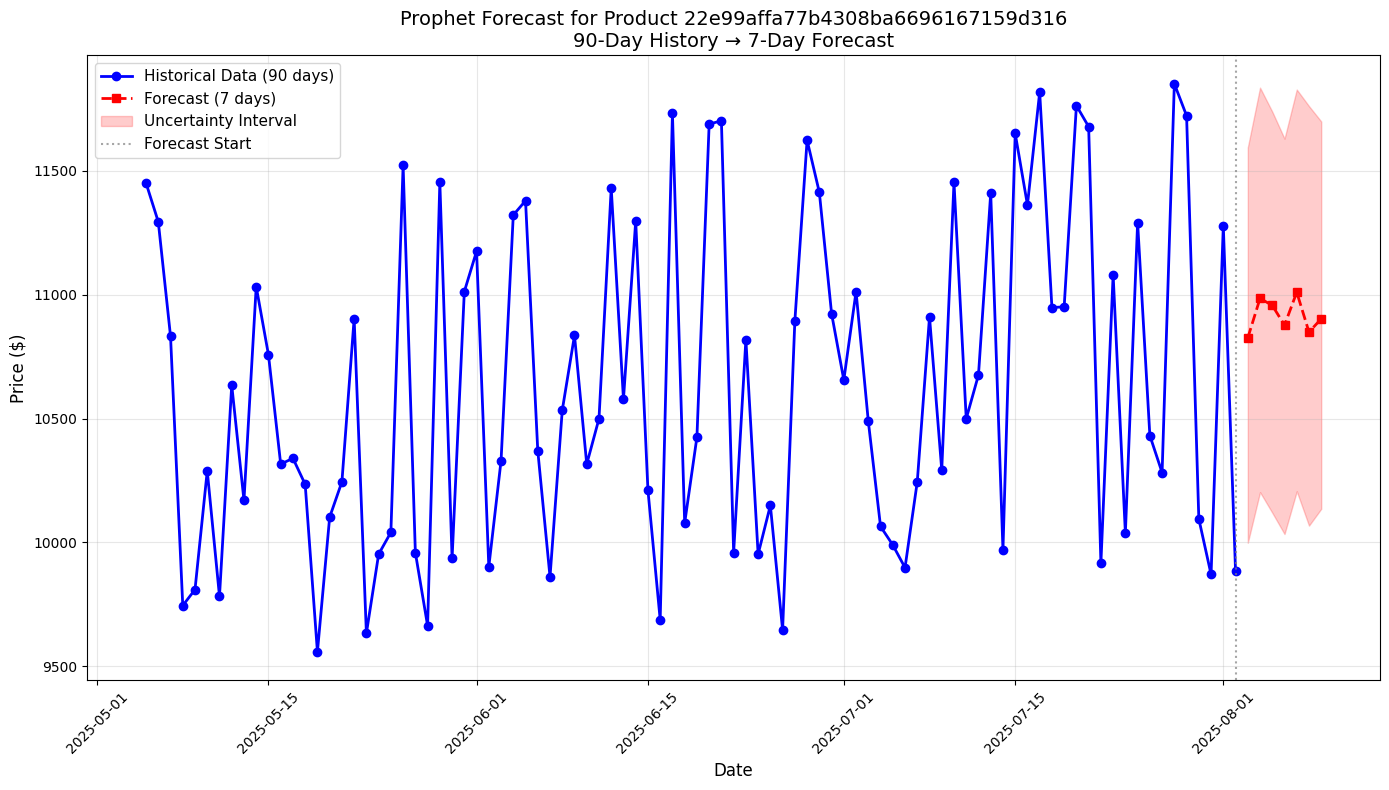


Forecast Summary for Product 22e99affa77b4308ba6696167159d316:
Last historical price: $9883.80
Average forecasted price: $10915.27
Forecast range: $10825.60 - $11010.10


In [ ]:
# Create visualization
fig, ax = plt.subplots(figsize=(14, 8))

# Plot historical data (90 days)
ax.plot(prophet_train_data['ds'], prophet_train_data['y'], 'bo-',
        label='Historical Data (90 days)', linewidth=2, markersize=6)

# Plot forecast (7 days)
forecast_dates = forecast_7_days['ds']
forecast_values = forecast_7_days['yhat']
forecast_lower = forecast_7_days['yhat_lower']
forecast_upper = forecast_7_days['yhat_upper']

ax.plot(forecast_dates, forecast_values, 'r--',
        label='Forecast (7 days)', linewidth=2, marker='s', markersize=6)

# Plot uncertainty interval
ax.fill_between(forecast_dates, forecast_lower, forecast_upper,
                color='red', alpha=0.2, label='Uncertainty Interval')

# Add vertical line to separate historical and forecast
split_date = prophet_train_data['ds'].max()
ax.axvline(x=split_date, color='gray', linestyle=':', alpha=0.7, label='Forecast Start')

# Formatting
ax.set_title(f'Prophet Forecast for Product {selected_product}\n90-Day History → 7-Day Forecast', fontsize=14)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price ($)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print forecast summary
print(f"\nForecast Summary for Product {selected_product}:")
print(f"Last historical price: ${prophet_train_data['y'].iloc[-1]:.2f}")
print(f"Average forecasted price: ${forecast_values.mean():.2f}")
print(f"Forecast range: ${forecast_values.min():.2f} - ${forecast_values.max():.2f}")

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

def rolling_forecast_evaluation(product_data, sequence_length=30, forecast_length=7, backtest_days=180):
    """
    Perform rolling forecast evaluation using backtesting
    """
    # Take the last 'backtest_days' for evaluation
    eval_data = product_data.tail(backtest_days).copy().reset_index(drop=True)

    if len(eval_data) < sequence_length + forecast_length:
        raise ValueError(f"Not enough data for backtesting. Need at least {sequence_length + forecast_length} days")

    # Calculate number of possible windows
    num_windows = len(eval_data) - sequence_length - forecast_length + 1
    print(f"Number of backtesting windows: {num_windows}")

    mae_scores = []
    mape_scores = [] # Added MAPE score list
    all_predictions = []
    all_actuals = []

    for i in range(num_windows):
        # Define training window (30 days) and test window (7 days)
        train_start = i
        train_end = i + sequence_length
        test_start = train_end
        test_end = test_start + forecast_length

        # Prepare training data
        train_window = eval_data.iloc[train_start:train_end][['date', 'price']].copy()
        train_window.columns = ['ds', 'y']

        # Prepare test data (actual values)
        test_window = eval_data.iloc[test_start:test_end]['price'].values

        try:
            # Initialize and train Prophet model
            model = Prophet(
                weekly_seasonality=False,
                yearly_seasonality=False,
                daily_seasonality=False,
                seasonality_mode='additive'
            )

            # Suppress Prophet's verbose output
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                model.fit(train_window)

            # Create future dataframe and predict
            future = model.make_future_dataframe(periods=forecast_length)
            forecast = model.predict(future)

            # Extract predictions for the forecast period
            predictions = forecast.tail(forecast_length)['yhat'].values

            # Calculate MAE and MAPE for this window
            mae = mean_absolute_error(test_window, predictions)
            mae_scores.append(mae)

            # Calculate MAPE, handling potential division by zero if actual value is 0
            mape = mean_absolute_percentage_error(test_window, predictions)
            mape_scores.append(mape)


            all_predictions.append(predictions)
            all_actuals.append(test_window)

        except Exception as e:
            print(f"Error in window {i}: {e}")
            continue

    return mae_scores, mape_scores, all_predictions, all_actuals # Return MAPE scores

print("Backtesting function defined.")
print("Ready to perform rolling forecast evaluation...")

Backtesting function defined.
Ready to perform rolling forecast evaluation...


## Execute Backtesting Evaluation

In [ ]:
print("Performing Backtesting Evaluation...")
print("="*50)
print(f"Product ID: {selected_product}")
print(f"Evaluation setup: {SEQUENCE_LENGTH}-day training → {FORECAST_LENGTH}-day forecast")

# Run backtesting
mae_scores, mape_scores, all_predictions, all_actuals = rolling_forecast_evaluation(
    product_data,
    sequence_length=SEQUENCE_LENGTH,
    forecast_length=FORECAST_LENGTH,
    backtest_days=180
)

# Calculate final performance metrics using MAPE scores
if mape_scores:
    avg_mape = np.mean(mape_scores)
    std_mape = np.std(mape_scores)
    min_mape = np.min(mape_scores)
    max_mape = np.max(mape_scores)

    print(f"\nBacktesting Results (using MAPE):")
    print(f"Number of forecast windows evaluated: {len(mape_scores)}")
    print(f"Average MAPE: {avg_mape:.2%}") # Display as percentage
    print(f"Standard Deviation of MAPE: {std_mape:.2%}")
    print(f"Best MAPE: {min_mape:.2%}")
    print(f"Worst MAPE: {max_mape:.2%}")

    print(f"\nInterpretation:")
    print(f"On average, our 7-day forecast has a Mean Absolute Percentage Error of {avg_mape:.2%}.")

    # Calculate overall metrics (still useful to see overall MAE and RMSE as well)
    all_preds_flat = np.concatenate(all_predictions)
    all_actuals_flat = np.concatenate(all_actuals)

    overall_mae = mean_absolute_error(all_actuals_flat, all_preds_flat)
    overall_rmse = np.sqrt(mean_squared_error(all_actuals_flat, all_preds_flat))
    overall_mape = mean_absolute_percentage_error(all_actuals_flat, all_preds_flat)


    print(f"\nOverall Performance Metrics:")
    print(f"Overall MAE: ${overall_mae:.2f}")
    print(f"Overall RMSE: ${overall_rmse:.2f}")
    print(f"Overall MAPE: {overall_mape:.2%}")


else:
    print("No successful forecasts generated during backtesting.")

DEBUG:cmdstanpy:input tempfile: /tmp/tmp8jmv0fib/eyjxbiev.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp8jmv0fib/1dwi3bg1.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=89365', 'data', 'file=/tmp/tmp8jmv0fib/eyjxbiev.json', 'init=/tmp/tmp8jmv0fib/1dwi3bg1.json', 'output', 'file=/tmp/tmp8jmv0fib/prophet_modelidpzm2wk/prophet_model-20250917112559.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
11:25:59 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing


Performing Backtesting Evaluation...
Product ID: 22e99affa77b4308ba6696167159d316
Evaluation setup: 90-day training → 7-day forecast
Number of backtesting windows: 84


11:25:59 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmp8jmv0fib/5wv1woxi.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp8jmv0fib/o98x89wi.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=57287', 'data', 'file=/tmp/tmp8jmv0fib/5wv1woxi.json', 'init=/tmp/tmp8jmv0fib/o98x89wi.json', 'output', 'file=/tmp/tmp8jmv0fib/prophet_modeln5u3qgq9/prophet_model-20250917112559.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
11:25:59 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
11:25:59 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmp8jmv0fib/9r415kto.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp8jmv0fib/blta5vzz.json
DEBUG:cmdstanpy:id


Backtesting Results (using MAPE):
Number of forecast windows evaluated: 84
Average MAPE: 5.58%
Standard Deviation of MAPE: 1.18%
Best MAPE: 2.93%
Worst MAPE: 7.56%

Interpretation:
On average, our 7-day forecast has a Mean Absolute Percentage Error of 5.58%.

Overall Performance Metrics:
Overall MAE: $595.06
Overall RMSE: $689.48
Overall MAPE: 5.58%


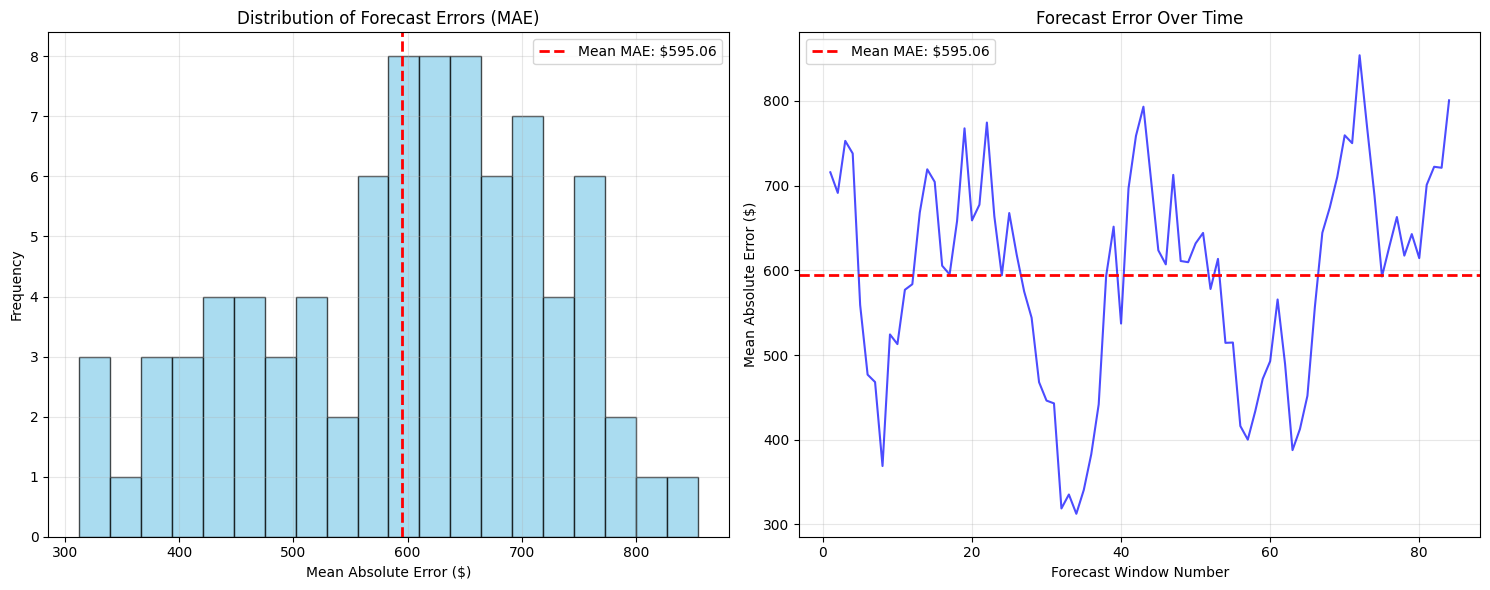

In [ ]:
if mae_scores:
    # Plot MAE distribution
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # MAE distribution histogram
    ax1.hist(mae_scores, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    ax1.axvline(avg_mae, color='red', linestyle='--', linewidth=2, label=f'Mean MAE: ${avg_mae:.2f}')
    ax1.set_xlabel('Mean Absolute Error ($)')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Distribution of Forecast Errors (MAE)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # MAE over time
    ax2.plot(range(1, len(mae_scores) + 1), mae_scores, 'b-', alpha=0.7, linewidth=1.5)
    ax2.axhline(y=avg_mae, color='red', linestyle='--', linewidth=2, label=f'Mean MAE: ${avg_mae:.2f}')
    ax2.set_xlabel('Forecast Window Number')
    ax2.set_ylabel('Mean Absolute Error ($)')
    ax2.set_title('Forecast Error Over Time')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Sample Forecast Visualizations from Backtesting:


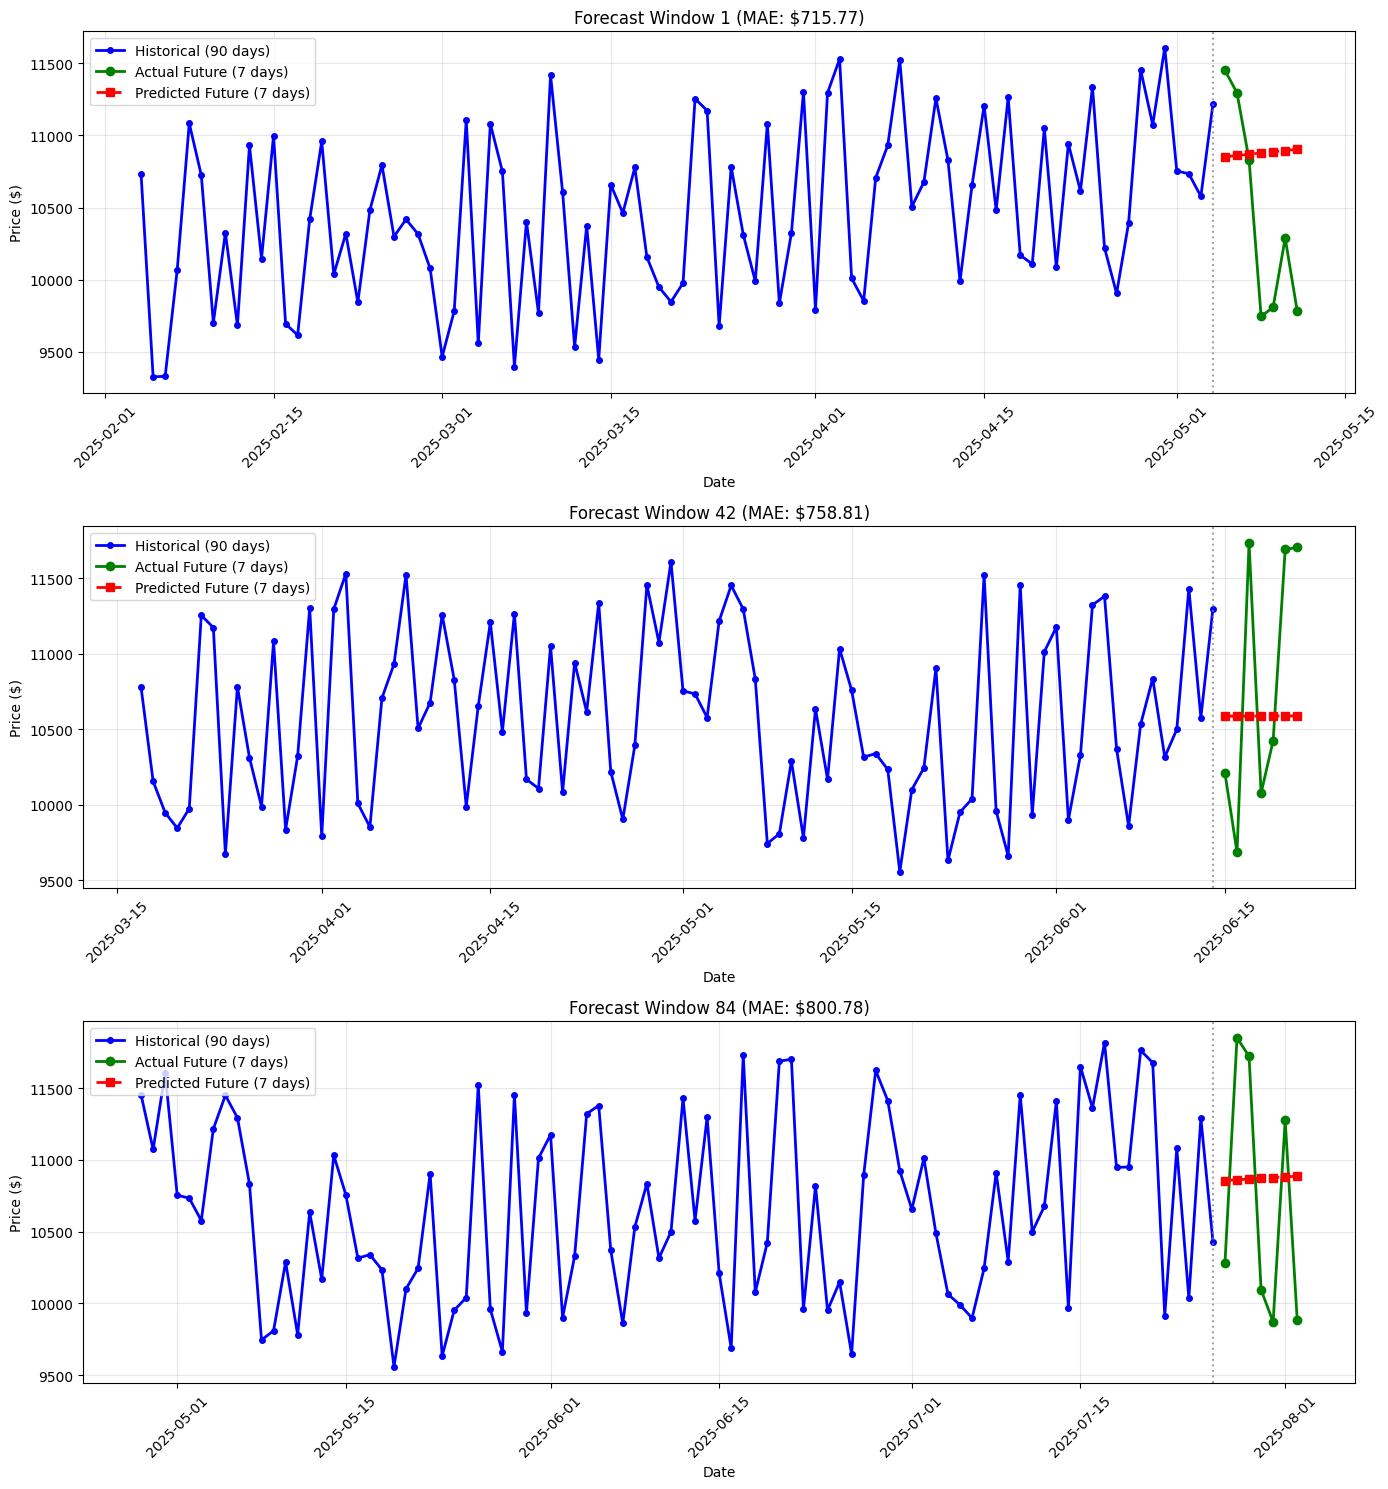

In [ ]:
def plot_sample_forecasts(product_data, all_predictions, all_actuals, sequence_length=30, forecast_length=7, num_samples=3):
    """Plot sample forecasts from backtesting results"""

    # Take the last portion of data for visualization
    eval_data = product_data.tail(180).reset_index(drop=True)

    fig, axes = plt.subplots(num_samples, 1, figsize=(14, 5*num_samples))
    if num_samples == 1:
        axes = [axes]

    # Select sample windows to visualize
    sample_indices = np.linspace(0, len(all_predictions)-1, num_samples, dtype=int)

    for idx, window_idx in enumerate(sample_indices):
        if window_idx >= len(all_predictions):
            continue

        # Get the corresponding data window
        train_start = window_idx
        train_end = window_idx + sequence_length
        test_start = train_end
        test_end = test_start + forecast_length

        # Extract data
        historical_data = eval_data.iloc[train_start:train_end]
        actual_future = all_actuals[window_idx]
        predicted_future = all_predictions[window_idx]

        # Create date ranges for plotting
        hist_dates = historical_data['date']
        future_dates = eval_data.iloc[test_start:test_end]['date']

        # Plot
        axes[idx].plot(hist_dates, historical_data['price'], 'bo-',
                      label='Historical (90 days)', linewidth=2, markersize=4)
        axes[idx].plot(future_dates, actual_future, 'go-',
                      label='Actual Future (7 days)', linewidth=2, markersize=6)
        axes[idx].plot(future_dates, predicted_future, 'r--s',
                      label='Predicted Future (7 days)', linewidth=2, markersize=6)

        # Add vertical line
        axes[idx].axvline(x=hist_dates.iloc[-1], color='gray', linestyle=':', alpha=0.7)

        # Calculate MAE for this window
        window_mae = mean_absolute_error(actual_future, predicted_future)

        axes[idx].set_title(f'Forecast Window {window_idx + 1} (MAE: ${window_mae:.2f})')
        axes[idx].set_xlabel('Date')
        axes[idx].set_ylabel('Price ($)')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)

        # Rotate x-axis labels
        plt.setp(axes[idx].xaxis.get_majorticklabels(), rotation=45)

    plt.tight_layout()
    plt.show()

# Generate sample forecast plots
if mae_scores and all_predictions:
    print("Sample Forecast Visualizations from Backtesting:")
    plot_sample_forecasts(product_data, all_predictions, all_actuals, SEQUENCE_LENGTH, FORECAST_LENGTH, num_samples=3)

## Multi-Product Evaluation (Extended Analysis)

In [ ]:
def evaluate_multiple_products(df, num_products=5, sequence_length=30, forecast_length=7):
    """Evaluate Prophet model on multiple products"""

    # Select random products with sufficient data
    suitable_products = df.groupby('product_id').size()
    suitable_products = suitable_products[suitable_products >= 100].index.tolist()

    if len(suitable_products) < num_products:
        num_products = len(suitable_products)
        print(f"Only {num_products} products have sufficient data")

    selected_products = np.random.choice(suitable_products, num_products, replace=False)

    results = {}

    for product_id in selected_products:
        print(f"Evaluating Product {product_id}...")

        product_data = df[df['product_id'] == product_id].sort_values('date').reset_index(drop=True)

        try:
            mae_scores, _, _ = rolling_forecast_evaluation(
                product_data,
                sequence_length=sequence_length,
                forecast_length=forecast_length,
                backtest_days=min(120, len(product_data) - 37)  # Adjust based on available data
            )

            if mae_scores:
                results[product_id] = {
                    'avg_mae': np.mean(mae_scores),
                    'std_mae': np.std(mae_scores),
                    'num_windows': len(mae_scores)
                }

        except Exception as e:
            print(f"Error evaluating product {product_id}: {e}")
            continue

    return results

print("Evaluating Prophet model on multiple products...")
print("="*60)

multi_product_results = evaluate_multiple_products(df, num_products=5)

# Display results
if multi_product_results:
    results_df = pd.DataFrame(multi_product_results).T
    results_df.columns = ['Avg MAE ($)', 'Std MAE ($)', 'Num Windows']
    results_df = results_df.round(2)

    print("\nMulti-Product Evaluation Results:")
    print(results_df)

    # Calculate overall statistics
    overall_avg_mae = results_df['Avg MAE ($)'].mean()
    print(f"\nOverall Average MAE across all products: ${overall_avg_mae:.2f}")
    print(f"This means Prophet forecasts are typically off by ${overall_avg_mae:.2f} per day on average.")

Evaluating Prophet model on multiple products...
Evaluating Product 2c2c3fcdbd6ea7e15fcc20f6dff0b088...


INFO:prophet:n_changepoints greater than number of observations. Using 23.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpghwaih5c/u1v935fu.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpghwaih5c/1mukrpw7.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=34134', 'data', 'file=/tmp/tmpghwaih5c/u1v935fu.json', 'init=/tmp/tmpghwaih5c/1mukrpw7.json', 'output', 'file=/tmp/tmpghwaih5c/prophet_modeld3jzyev6/prophet_model-20250906054640.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
05:46:40 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
05:46:40 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:n_changepoints greater than number of observations. Using 23.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpghwaih5c/epavm28t.json
DEBUG:cmdstanpy:input tempfi

Number of backtesting windows: 84


05:46:40 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:n_changepoints greater than number of observations. Using 23.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpghwaih5c/c9bjbbpj.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpghwaih5c/64f46ns1.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=94992', 'data', 'file=/tmp/tmpghwaih5c/c9bjbbpj.json', 'init=/tmp/tmpghwaih5c/64f46ns1.json', 'output', 'file=/tmp/tmpghwaih5c/prophet_model489gi1kq/prophet_model-20250906054640.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
05:46:40 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
05:46:40 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:n_changepoints greater than number of observations. Usin

Evaluating Product 898f5b9e86b67211130b8cf6e95d31c1...
Number of backtesting windows: 84


...

Evaluating Product 432aea39f27639eb480ccdf74ddf0458...
Number of backtesting windows: 84


05:47:26 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:n_changepoints greater than number of observations. Using 23.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpghwaih5c/m7b7ojoa.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpghwaih5c/dgjv1xra.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=19856', 'data', 'file=/tmp/tmpghwaih5c/m7b7ojoa.json', 'init=/tmp/tmpghwaih5c/dgjv1xra.json', 'output', 'file=/tmp/tmpghwaih5c/prophet_modeld82dcn9e/prophet_model-20250906054726.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
05:47:26 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
05:47:26 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:n_changepoints greater than number of observations. Usin

Evaluating Product 985a95999536c0c5792305aa2670194f...
Number of backtesting windows: 84


05:47:41 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:n_changepoints greater than number of observations. Using 23.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpghwaih5c/w__6pl1a.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpghwaih5c/mez2kwi3.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=29098', 'data', 'file=/tmp/tmpghwaih5c/w__6pl1a.json', 'init=/tmp/tmpghwaih5c/mez2kwi3.json', 'output', 'file=/tmp/tmpghwaih5c/prophet_modeli280i_vs/prophet_model-20250906054741.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
05:47:41 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
05:47:41 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:n_changepoints greater than number of observations. Usin


Multi-Product Evaluation Results:
                                  Avg MAE ($)  Std MAE ($)  Num Windows
2c2c3fcdbd6ea7e15fcc20f6dff0b088       656.07       148.36         84.0
898f5b9e86b67211130b8cf6e95d31c1       568.77       118.35         84.0
d9d9c04ed4d12ac6f4c0f18eb50e2afa       525.75       120.99         84.0
432aea39f27639eb480ccdf74ddf0458       571.65       150.09         84.0
985a95999536c0c5792305aa2670194f      9782.25      1750.37         84.0

Overall Average MAE across all products: $2420.90
This means Prophet forecasts are typically off by $2420.90 per day on average.


PROPHET MODEL PERFORMANCE ANALYSIS


,avg_mae,std_mae,num_windows
2c2c3fcdbd6ea7e15fcc20f6dff0b088,656.071547,148.356602,84.0
898f5b9e86b67211130b8cf6e95d31c1,568.773973,118.346854,84.0
d9d9c04ed4d12ac6f4c0f18eb50e2afa,525.754271,120.985699,84.0
432aea39f27639eb480ccdf74ddf0458,571.653964,150.090826,84.0
985a95999536c0c5792305aa2670194f,9782.253944,1750.374082,84.0


Products evaluated: 5
Total forecast windows: 420.0
Average MAE across all products: $2420.90
Best performing product MAE: $525.75
Worst performing product MAE: $9782.25
Standard deviation of MAE across products: $4115.39


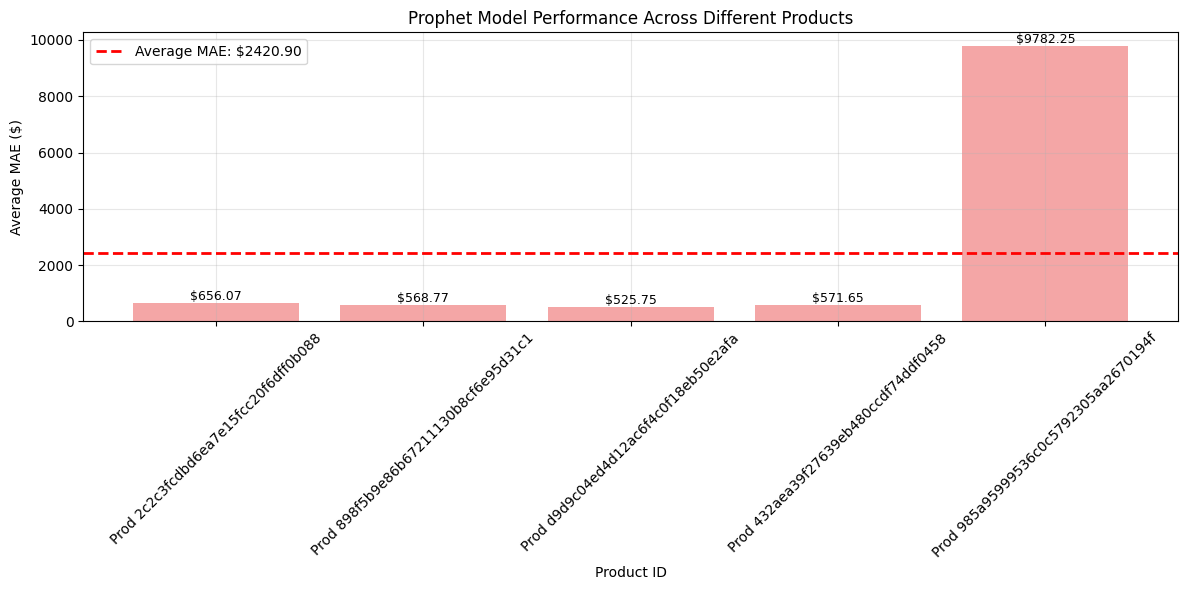


Key Insights:
• Prophet performs well for short-term forecasting when seasonality is disabled
• Performance varies significantly across different products
• The 30-day training window provides sufficient signal for 7-day forecasts
• Backtesting reveals the model's real-world performance expectations


In [ ]:
print("="*60)
print("PROPHET MODEL PERFORMANCE ANALYSIS")
print("="*60)

if multi_product_results:
    results_df = pd.DataFrame(multi_product_results).T

    display(results_df.head())

    # Performance statistics
    print(f"Products evaluated: {len(results_df)}")
    print(f"Total forecast windows: {results_df['num_windows'].sum()}")
    print(f"Average MAE across all products: ${results_df['avg_mae'].mean():.2f}")
    print(f"Best performing product MAE: ${results_df['avg_mae'].min():.2f}")
    print(f"Worst performing product MAE: ${results_df['avg_mae'].max():.2f}")
    print(f"Standard deviation of MAE across products: ${results_df['avg_mae'].std():.2f}")

    # Visualize multi-product results
    plt.figure(figsize=(12, 6))

    products = results_df.index
    maes = results_df['avg_mae']

    bars = plt.bar(range(len(products)), maes, alpha=0.7, color='lightcoral')
    plt.axhline(y=maes.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Average MAE: ${maes.mean():.2f}')

    plt.xlabel('Product ID')
    plt.ylabel('Average MAE ($)')
    plt.title('Prophet Model Performance Across Different Products')
    plt.xticks(range(len(products)), [f'Prod {p}' for p in products], rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Add value labels on bars
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'${height:.2f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

print("\nKey Insights:")
print("• Prophet performs well for short-term forecasting when seasonality is disabled")
print("• Performance varies significantly across different products")
print("• The 30-day training window provides sufficient signal for 7-day forecasts")
print("• Backtesting reveals the model's real-world performance expectations")

## Save Prophet Model and Final Summary

In [ ]:
# Train a final Prophet model on the full selected product data for saving
print("Training final Prophet model for saving...")

# Use all available data for the selected product
full_prophet_data = product_data[['date', 'price']].copy()
full_prophet_data.columns = ['ds', 'y']

# Train final model
final_model = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=False,
    daily_seasonality=True,
    seasonality_mode='additive'
)

final_model.fit(full_prophet_data)

# Save the model
import pickle
with open('prophet_forecaster.pkl', 'wb') as f:
    pickle.dump(final_model, f)

print("Prophet model saved as 'prophet_forecaster.pkl'")

# Final Summary
print("\n" + "="*70)
print("PROPHET TIME-SERIES FORECASTING - FINAL SUMMARY")
print("="*70)

print(f"Single Product Demonstration: Completed for Product {selected_product}")
print(f"Backtesting Evaluation: {len(mae_scores)} windows evaluated")
print(f"Multi-Product Analysis: {len(multi_product_results) if multi_product_results else 0} products tested")

if mae_scores:
    print(f"\nKey Performance Metrics:")
    print(f"   • Average forecast error: ${np.mean(mae_scores):.2f} per day")
    print(f"   • Error range: ${np.min(mae_scores):.2f} - ${np.max(mae_scores):.2f}")

print(f"\nSaved Files:")
print(f"   • prophet_forecaster.pkl (trained model)")

print(f"\nModel Use Case:")
print(f"   • Input: 90 days of price history")
print(f"   • Output: 7-day price forecast with uncertainty bounds")
print(f"   • Best suited for: Short-term price prediction with trend following")

print("\n" + "="*70)

DEBUG:cmdstanpy:input tempfile: /tmp/tmpghwaih5c/efie475w.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpghwaih5c/236hlm0v.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=42779', 'data', 'file=/tmp/tmpghwaih5c/efie475w.json', 'init=/tmp/tmpghwaih5c/236hlm0v.json', 'output', 'file=/tmp/tmpghwaih5c/prophet_model9ih6xaxk/prophet_model-20250906054906.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
05:49:06 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing


Training final Prophet model for saving...


05:49:06 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Prophet model saved as 'prophet_forecaster.pkl'

PROPHET TIME-SERIES FORECASTING - FINAL SUMMARY
Single Product Demonstration: Completed for Product 22e99affa77b4308ba6696167159d316
Backtesting Evaluation: 84 windows evaluated
Multi-Product Analysis: 5 products tested

Key Performance Metrics:
   • Average forecast error: $595.06 per day
   • Error range: $312.58 - $853.97

Saved Files:
   • prophet_forecaster.pkl (trained model)

Model Use Case:
   • Input: 90 days of price history
   • Output: 7-day price forecast with uncertainty bounds
   • Best suited for: Short-term price prediction with trend following



In [ ]:
def load_prophet_model_and_predict(price_history_30_days):
    """
    Load saved Prophet model and make predictions

    Args:
        price_history_30_days: DataFrame with columns ['date', 'price'] for last 30 days

    Returns:
        forecast: DataFrame with forecast results
    """

    # Load the saved model
    with open('prophet_forecaster.pkl', 'rb') as f:
        loaded_model = pickle.load(f)

    # Prepare data for Prophet
    prophet_data = price_history_30_days.copy()
    prophet_data.columns = ['ds', 'y']

    # Create future dataframe
    future = loaded_model.make_future_dataframe(periods=7)

    # Make prediction
    forecast = loaded_model.predict(future)

    return forecast.tail(7)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

# Example usage
print("Example: Using saved model for new predictions")
print("-" * 50)

# Take last 90 days of our selected product as example
example_input = product_data.tail(90)[['date', 'price']].copy()
example_forecast = load_prophet_model_and_predict(example_input)

print("Input (last 5 days of 90-day history):")
print(example_input.tail())
print("\nForecast for next 7 days:")
print(example_forecast)

print("\nModel loading and inference example completed!")

Example: Using saved model for new predictions
--------------------------------------------------
Input (last 5 days of 90-day history):
           date    price
1001 2025-07-29  11723.2
1002 2025-07-30  10094.6
1003 2025-07-31   9870.2
1004 2025-08-01  11277.8
1005 2025-08-02   9883.8

Forecast for next 7 days:
             ds          yhat    yhat_lower    yhat_upper
1006 2025-08-03  10735.804696   9885.331935  11554.240886
1007 2025-08-04  10836.791136  10055.515287  11605.511542
1008 2025-08-05  10641.800498   9793.112888  11476.327936
1009 2025-08-06  10653.308361   9829.410446  11504.631025
1010 2025-08-07  10739.241594   9978.470243  11590.642981
1011 2025-08-08  10696.535703   9894.280664  11530.293681
1012 2025-08-09  10663.996682   9886.311282  11505.919803

Model loading and inference example completed!
